<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task

In [101]:
%pip install pygad

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import pygad

In [103]:
class Product():
  """Represents any product by given name, space and price."""
  def __init__(self, name: str, space: float, price: float) -> None:
    self.name = name
    self.space = space
    self.price = price

In [104]:
products_list = []
products_list.append(Product('Refrigerator A', 0.751, 999.90))
products_list.append(Product('Cell phone', 0.00000899, 2199.12))
products_list.append(Product('TV 55', 0.400, 4346.99))
products_list.append(Product("TV 50' ", 0.290, 3999.90))
products_list.append(Product("TV 42' ", 0.200, 2999.00))
products_list.append(Product("Notebook A", 0.00350, 2499.90))
products_list.append(Product("Ventilator", 0.496, 199.90))
products_list.append(Product("Microwave A", 0.0424, 308.66))
products_list.append(Product("Microwave B", 0.0544, 429.90))
products_list.append(Product("Microwave C", 0.0319, 299.29))
products_list.append(Product("Refrigerator B", 0.635, 849.00))
products_list.append(Product("Refrigerator C", 0.870, 1199.89))
products_list.append(Product("Notebook B", 0.498, 1999.90))
products_list.append(Product("Notebook C", 0.527, 3999.00))


In [105]:
spaces = [product.space for product in products_list]
prices = [product.price for product in products_list]
names = [product.name for product in products_list]

In [106]:
for product in products_list:
  print(product.name, ' - ', product.price, ' - ', product.space)

Refrigerator A  -  999.9  -  0.751
Cell phone  -  2199.12  -  8.99e-06
TV 55  -  4346.99  -  0.4
TV 50'   -  3999.9  -  0.29
TV 42'   -  2999.0  -  0.2
Notebook A  -  2499.9  -  0.0035
Ventilator  -  199.9  -  0.496
Microwave A  -  308.66  -  0.0424
Microwave B  -  429.9  -  0.0544
Microwave C  -  299.29  -  0.0319
Refrigerator B  -  849.0  -  0.635
Refrigerator C  -  1199.89  -  0.87
Notebook B  -  1999.9  -  0.498
Notebook C  -  3999.0  -  0.527


In [107]:
space_limit = 3

def fitness_func(ga_instance, solution, solution_idx):

    total_space = 0
    total_price = 0

    for i in range(len(solution)):
        if solution[i] == 1:
            total_space += spaces[i]
            total_price += prices[i]

            if total_space > space_limit:
                return 0

    return total_price

In [108]:
fitness_function = fitness_func

num_generations = 50
num_parents_mating = 4

sol_per_pop = 8
num_genes = len(products_list)

gene_space = [0, 1]
gene_type = int

parent_selection_type = "sss"
keep_parents = 1

crossover_type = "single_point"

mutation_type = "random"
mutation_percent_genes = 10

In [109]:
ga_instance = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=fitness_function,

    sol_per_pop=sol_per_pop,
    num_genes=num_genes,

    gene_space=gene_space,
    gene_type=gene_type,

    parent_selection_type=parent_selection_type,
    keep_parents=keep_parents,

    crossover_type=crossover_type,

    mutation_type=mutation_type,
    mutation_percent_genes=mutation_percent_genes
)

In [110]:
ga_instance.run()
solution, fitness, solution_idx = ga_instance.best_solution()

In [111]:
print("Initial population:")
print(ga_instance.population)

Initial population:
[[0 1 1 1 1 1 0 1 1 1 0 1 1 1]
 [0 1 1 1 1 1 0 1 1 1 0 1 0 1]
 [1 1 1 1 1 0 0 1 1 0 0 1 1 0]
 [0 1 1 1 1 1 0 1 1 1 0 1 1 1]
 [0 1 1 1 0 0 0 1 1 1 0 1 1 1]
 [0 1 1 1 1 1 0 1 1 0 1 0 0 1]
 [1 1 1 1 1 0 0 1 1 0 0 1 1 0]
 [0 1 1 1 1 1 0 0 1 0 0 1 1 1]]


In [112]:
print("Best solution:")
print(solution)

print("\nFitness:", fitness)

Best solution:
[0 1 1 1 1 1 0 1 1 1 0 1 1 1]

Fitness: 24281.550000000003


In [113]:
print("Selected products:")

total_space = 0
total_price = 0

for i in range(len(solution)):
    if solution[i] == 1:
        print(names[i])

        total_space += spaces[i]
        total_price += prices[i]

print(f"\nTotal volume: {total_space:.3f} m³")
print(f"Total price: ${total_price:.2f}")

Selected products:
Cell phone
TV 55
TV 50' 
TV 42' 
Notebook A
Microwave A
Microwave B
Microwave C
Refrigerator C
Notebook B
Notebook C

Total volume: 2.917 m³
Total price: $24281.55


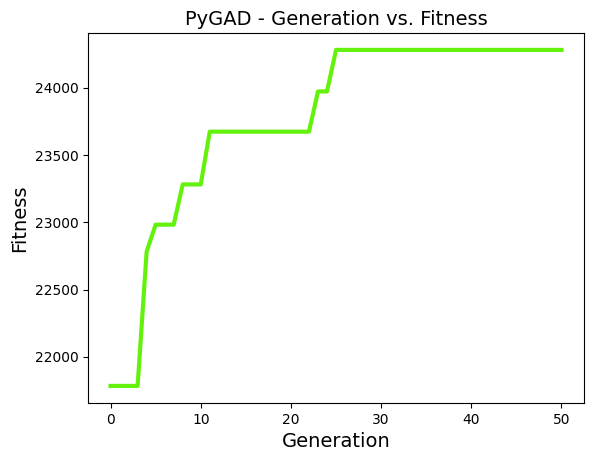

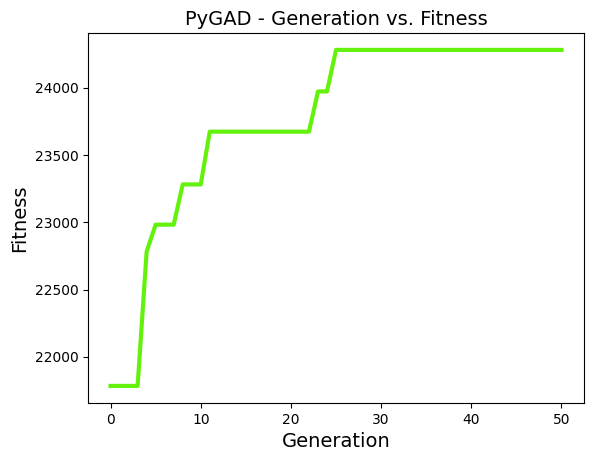

In [114]:
ga_instance.plot_fitness()

In [115]:
def run_experiment(crossover_type, mutation_percent_genes):

    ga_instance = pygad.GA(
        num_generations=50,
        num_parents_mating=4,
        fitness_func=fitness_function,

        random_seed=42,

        sol_per_pop=10,
        num_genes=len(products_list),

        gene_space=[0,1],
        gene_type=int,

        parent_selection_type="sss",
        keep_parents=1,

        crossover_type=crossover_type,

        mutation_type="random",
        mutation_percent_genes=mutation_percent_genes
    )

    ga_instance.run()

    solution, fitness, solution_idx = ga_instance.best_solution()

    return fitness

In [116]:
results = []

In [117]:
crossovers = [
    "single_point",
    "two_points",
    "uniform"
]

for crossover in crossovers:

    fitness = run_experiment(crossover, 10)

    results.append({
        "Experiment": "Crossover",
        "Crossover": crossover,
        "Mutation (%)": 10,
        "Fitness": fitness
    })

In [118]:
mutations = [5, 10, 20, 40]

for mutation in mutations:

    fitness = run_experiment("uniform", mutation)

    results.append({
        "Experiment": "Mutation",
        "Crossover": "uniform",
        "Mutation (%)": mutation,
        "Fitness": fitness
    })

/usr/local/lib/python3.12/dist-packages/pygad/utils/validation.py:986: UserWarning: The percentage of genes to mutate (mutation_percent_genes=5) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


In [119]:
pd.DataFrame(results)

,Experiment,Crossover,Mutation (%),Fitness
0,Crossover,single_point,10,24281.55
1,Crossover,two_points,10,24081.56
2,Crossover,uniform,10,24281.55
3,Mutation,uniform,5,24281.55
4,Mutation,uniform,10,24281.55
5,Mutation,uniform,20,23930.66
6,Mutation,uniform,40,21631.47


# Summary

The experiments showed that the type of crossover affects the quality of the obtained solution. The best result was obtained when using two_points and uniform crossovers, which provided the same maximum value of the fitness function (24281.55). The single_point crossover showed a slightly lower result (24081.56).

Analysis of the mutation level showed that values ​​of 10–20% provide the best quality of the solution. When the mutation was increased to 40%, the fitness function value decreased to 23343.00, which indicates excessive randomness of the search and destruction of already found good solutions.